In [1]:
import os
from collections import defaultdict

import numpy as np
from astropy.io import fits
import pandas as pd

from astropy.convolution import convolve
from astropy.stats import SigmaClip
from photutils.background import Background2D, MedianBackground
from photutils.segmentation import detect_sources, SourceCatalog
from photutils.psf import IntegratedGaussianPRF

In [2]:
def load_focusing_images(base_dir, target_group_ids=None, prefix="focustest_gcode4_5000_20250915_"):
    from collections import defaultdict
    import os
    import numpy as np
    from astropy.io import fits

    group_dict = defaultdict(lambda: {"fits": [], "meta": None})

    for fname in os.listdir(base_dir):
        if prefix is not None and (not fname.startswith(prefix)):
            continue

        fpath = os.path.join(base_dir, fname)
        base, ext = os.path.splitext(fname)
        parts = fname.split("_")
        group_id = parts[-2]

        if ext == ".fits":
            idx_str = os.path.splitext(parts[-1])[0]
            idx = int(idx_str)
            group_dict[group_id]["fits"].append((idx, fpath))
        elif fname.endswith("_meta.json"):
            group_dict[group_id]["meta"] = fpath

    for gid, entry in group_dict.items():
        entry["fits"].sort(key=lambda x: x[0])

    images_dict = {}
    meta_dict = {}

    for gid, entry in group_dict.items():
        if (target_group_ids is not None) and (gid not in target_group_ids):
            continue

        image_list = []
        for idx, fpath in entry["fits"]:
            print(f"[{gid}] Loading idx={idx}: {fpath}")
            with fits.open(fpath) as hdul:
                image_list.append(hdul[1].data)

        if image_list:
            images_dict[gid] = np.array(image_list)

        meta_dict[gid] = entry["meta"]

    return images_dict, meta_dict

In [ ]:
base_dir = "./FOCUSING_20250915"
target_group_ids = [
 '00000', '00003', '00004', '00005', '00006',
 '00007', '00008', '00009', '00010', '00011', '00012'
]
#特に指定しない場合はtarget_group_ids=target_group_idsを消す。
images_dict, meta_dict = load_focusing_images(base_dir, target_group_ids=target_group_ids)


In [ ]:
print(images_dict.keys())

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import gridspec

def show_focus_group(image_dict, group_id, vmin=75, vmax=150):
    """
    image_dict[group_id] 内の画像を、
    元コードと同じ 1x6 グリッドで表示する
    """

    if group_id not in image_dict:
        print(f"Group ID {group_id} was not found.")
        return

    image_list = image_dict[group_id]   # shape = (N, H, W)
    n_images = len(image_list)

    # --- Figure レイアウト（あなたの元コードをそのまま踏襲） ---
    fig = plt.figure(figsize=(12, 12))
    gs = gridspec.GridSpec(1, n_images, hspace=0, wspace=0.1)
    plt.subplots_adjust(wspace=0, hspace=0)

    axs = [fig.add_subplot(gs[0, i]) for i in range(n_images)]

    # --- 画像ごとの描画 ---
    for i, ax in enumerate(axs):
        ax.set_title(f"CMOS {i}", ha='center', va='center')
        ax.set_xticks([])
        ax.set_yticks([])
        ax.imshow(image_list[i], vmin=vmin, vmax=vmax, origin='lower')

    plt.show()


In [ ]:
show_focus_group(images_dict, "00012")

In [ ]:
from photutils.psf import CircularGaussianSigmaPRF
from astropy.convolution import convolve
# ほか Background2D, MedianBackground などは今まで通り

def detection(data, nrows, ncols,
              sigma=5.0,
              threshold_sigma=5.0,
              pixel_scale=0.23):

    # 背景推定
    bkg = Background2D(
        data,
        box_size=50,
        filter_size=3,
        bkg_estimator=MedianBackground()
    )
    data_sub = data - bkg.background

    # --- PSF（CircularGaussianSigmaPRF, sigma 指定） ---
    psf_model = CircularGaussianSigmaPRF(sigma=sigma)

    y, x = np.mgrid[-5:6, -5:6]
    psf = psf_model(x, y)
    psf /= np.sum(psf)

    smoothed = convolve(data_sub, psf)

    # （以下は今までの detection と同じでOK）
    threshold = threshold_sigma * bkg.background_rms_median
    segm = detect_sources(smoothed, threshold, npixels=5)

    cat = SourceCatalog(data_sub, segm)
    print(f"検出した天体の数: {len(cat)}")

    a_sigma = cat.semimajor_sigma.value
    b_sigma = cat.semiminor_sigma.value
    sigma_mean = np.sqrt(a_sigma * b_sigma)
    fwhm_pix = sigma_mean * (2 * np.sqrt(2 * np.log(2)))
    fwhm_arcsec = fwhm_pix * pixel_scale
    pa_rad = cat.orientation.to("rad").value
    pa_deg = np.degrees(pa_rad)

    det_smooth = pd.DataFrame({
        "ID": np.arange(1, len(cat) + 1),
        "xcentroid": cat.xcentroid,
        "ycentroid": cat.ycentroid,
        "segment_flux": cat.segment_flux,
        "a_sigma": a_sigma,
        "b_sigma": b_sigma,
        "fwhm_pix": fwhm_pix,
        "fwhm_arcsec": fwhm_arcsec,
        "b/a": b_sigma / a_sigma,
        "pa_deg": pa_deg,
    })

    # NaN ケア & grid_id 部分はさっきの修正版そのままでOK
    # （ここは省略するけど今使ってる NaN フィルタ付きのやつを貼り替えてね）

    return segm, cat, det_smooth


In [ ]:
from dask import delayed
from dask.distributed import get_client, as_completed
from tqdm.auto import tqdm

def run_detection_on_all_dask(
    image_dict,
    nrows,
    ncols,
    sigma=3.0,
    threshold_sigma=5.0,
    pixel_scale=0.168,
):
    """
    image_dict 内のすべての group_id / frame に対して detection() を実行し、
    結果をネストした dict にして返す（Dask distributed 使用）。

    return:
        detection_results[group_id] = [
            {
                "index": idx,
                "segm": segm,
                "catalog": cat,
                "table": det_smooth,
            },
            ...
        ]
    """
    client = get_client()

    delayed_tasks = []
    keys = []  # (gid, idx)

    for gid, imgs in image_dict.items():
        for idx, img in enumerate(imgs):
            keys.append((gid, idx))
            task = delayed(detection)(
                img,
                nrows=nrows,
                ncols=ncols,
                sigma=sigma,
                threshold_sigma=threshold_sigma,
                pixel_scale=pixel_scale,
            )
            delayed_tasks.append(task)

    print(f"Total tasks: {len(delayed_tasks)}")

    # 遅延タスク → Future に
    futures = client.compute(delayed_tasks)

    # Future → (gid, idx) の対応辞書
    future_to_key = {fut: key for fut, key in zip(futures, keys)}

    detection_results = {}

    # 進捗バー付きで結果を回収
    for fut in tqdm(as_completed(futures), total=len(futures)):
        segm, cat, det_smooth = fut.result()
        gid, idx = future_to_key[fut]

        detection_results.setdefault(gid, []).append({
            "index": idx,
            "segm": segm,
            "catalog": cat,
            "table": det_smooth,
        })

    # index 順にソート
    for gid in detection_results:
        detection_results[gid].sort(key=lambda d: d["index"])

    return detection_results


In [ ]:
from dask.distributed import Client
import time

client = Client(processes=True, n_workers=14, threads_per_worker=2)
print(client)

nrows, ncols = 4, 5

t0 = time.time()

det_results = run_detection_on_all_dask(
    images_dict,
    nrows=nrows,
    ncols=ncols,
    sigma=5.0,            # 単発テストと同じ
    threshold_sigma=5.0,  # 単発テストと同じ
    pixel_scale=0.23,
)

t1 = time.time()
print(f"\n>>> detection finished in {t1 - t0:.3f} seconds")


In [10]:
import matplotlib.pyplot as plt
from matplotlib import gridspec
import numpy as np

def show_focus_group_with_detections(image_dict, det_results, group_id,
                                     vmin=75, vmax=150, s=5):
    """
    すでに Dask などで計算済みの det_results を使って、
    image_dict[group_id] の各CMOS画像に検出位置を重ねて表示する。

    Parameters
    ----------
    image_dict : dict
        {group_id: [img0, img1, ...]} の形の辞書
    det_results : dict
        run_detection_on_all_local / run_detection_on_all_dask が返した結果。
        det_results[gid] は各フレームの dict のリストを想定。
    group_id : hashable
        表示したいキー（例: "00012"）
    vmin, vmax : float
        imshow の表示レンジ（全コマで揃える）
    s : float
        検出マーカーのサイズ（scatter の s）
    """

    # --- 存在チェック ---
    if group_id not in image_dict:
        print(f"Group ID {group_id} was not found in image_dict.")
        return

    if group_id not in det_results:
        print(f"Group ID {group_id} was not found in det_results.")
        return

    image_list = image_dict[group_id]
    n_images = len(image_list)

    # det_results[group_id] を index → record の dict にしておく
    frame_results = det_results[group_id]  # list of dicts
    idx_to_record = {rec["index"]: rec for rec in frame_results}

    # --- Figure レイアウト（元の show_focus_group と同じ 1 x N グリッド） ---
    fig = plt.figure(figsize=(12, 12))
    gs = gridspec.GridSpec(1, n_images, hspace=0, wspace=0.1)
    plt.subplots_adjust(wspace=0, hspace=0)

    axs = [fig.add_subplot(gs[0, i]) for i in range(n_images)]

    # --- 各CMOSごとに描画 ---
    for i, (img, ax) in enumerate(zip(image_list, axs)):
        ax.set_title(f"CMOS {i}", ha='center', va='center', fontsize=10)
        ax.set_xticks([])
        ax.set_yticks([])

        # 画像本体
        ax.imshow(img, vmin=vmin, vmax=vmax, origin='lower', cmap='gray')

        # このフレームに対応する detection 結果があればマーカーを描画
        if i in idx_to_record:
            det_smooth = idx_to_record[i]["table"]  # pandas DataFrame
            if len(det_smooth) > 0:
                ax.scatter(
                    det_smooth["xcentroid"],
                    det_smooth["ycentroid"],
                    s=s,
                    edgecolors='red',
                    facecolors='none',  # 中抜き円にしたい場合
                    lw=0.5,
                )

    plt.show()


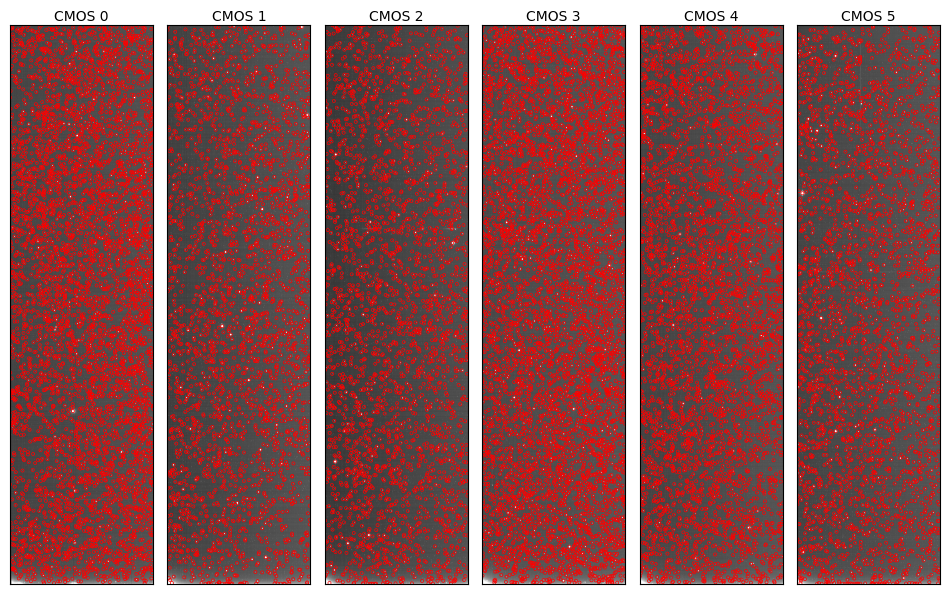

In [11]:
show_focus_group_with_detections(
    images_dict,
    det_results,
    "00012",   # ← dict の key（group_id）
    vmin=75,
    vmax=150,
    s=5,
)

In [12]:
def input_focus_positions(images_dict):
    """
    images_dict の key（例 "00002"）ごとに、
    ユーザーに a, b, c のアクチュエータ距離を入力させ、
    辞書として返す。

    Returns
    -------
    focus_meta : dict
        例:
        {
            "00001": {"a": 10.0, "b": 20.0, "c": 30.5},
            "00002": {"a": 11.2, "b": 21.4, "c": 29.9},
            ...
        }
    """

    focus_meta = {}

    print("\n=== Focusing Position Input ===\n")
    print("Enter actuator distances for each group.")
    print("If a value is unknown, press Enter to skip.\n")

    # 全キーを昇順で並べる（任意）
    for gid in sorted(images_dict.keys()):
        print(f"\n--- Group ID: {gid} ---")

        # 入力を読み込み（空なら None）
        def ask_float(name):
            val = input(f"  {name} distance (mm): ")
            return float(val) if val.strip() != "" else None

        a = ask_float("a")
        b = ask_float("b")
        c = ask_float("c")

        focus_meta[gid] = {
            "a": a,
            "b": b,
            "c": c
        }

    print("\n=== Input Completed ===\n")
    return focus_meta


In [ ]:
focus_meta = input_focus_positions(images_dict)


=== Focusing Position Input ===

Enter actuator distances for each group.
If a value is unknown, press Enter to skip.


--- Group ID: 00000 ---


for gid, meta in focus_meta.items():
    a = meta.get("a", np.nan)
    b = meta.get("b", np.nan)
    c = meta.get("c", np.nan)

    # a,b,c の平均を計算して "ave" として保存
    meta["ave"] = np.nanmean([a, b, c])


In [85]:
from astropy.stats import SigmaClip
import numpy as np

# group_id → (CMOS_idx → {"mean": ..., "err": ...})
fwhm_map = {}

sigma_clip = SigmaClip(sigma=3.0, maxiters=5)  # パラメータは好みで

for gid, frames in det_results.items():
    fwhm_map[gid] = {}
    for rec in frames:
        idx = rec["index"]      # CMOS番号
        df  = rec["table"]      # 検出天体テーブル

        vals = df["fwhm_arcsec"].values.astype(float)

        # NaN を一回落としておく（念のため）
        vals = vals[~np.isnan(vals)]
        if len(vals) == 0:
            fwhm_map[gid][idx] = {"mean": np.nan, "err": np.nan}
            continue

        # --- sigma clip ---
        clipped = sigma_clip(vals)  # MaskedArray が返る
        good = clipped.data[~clipped.mask]

        if len(good) == 0:
            # クリップで全部飛んだ場合
            fwhm_map[gid][idx] = {"mean": np.nan, "err": np.nan}
            continue

        # クリップ後の平均
        mean_fwhm = np.mean(good)
        ave_fwhm = np.average(good)

        # 誤差（標準誤差）: σ / √N
        if len(good) > 1:
            std_fwhm = np.std(good, ddof=1)
            err_fwhm = std_fwhm / np.sqrt(len(good))
        else:
            std_fwhm = 0.0
            err_fwhm = np.nan  # 1点だけなら誤差は定義しづらいので NaN にしておく

        fwhm_map[gid][idx] = {
            "mean": mean_fwhm,
            "err": err_fwhm,
            "ave": ave_fwhm,
        }


# group_id → (CMOS_idx → 平均FWHM)
fwhm_map = {}

for gid, frames in det_results.items():
    fwhm_map[gid] = {}
    for rec in frames:
        idx = rec["index"]                    # CMOS番号
        df  = rec["table"]                    # 検出天体テーブル
        mean_fwhm = np.nanmean(df["fwhm_arcsec"].values)
        fwhm_map[gid][idx] = mean_fwhm        # 例: fwhm_map["00000"][0] = 1.23

In [86]:
for gid, meta in focus_meta.items():
    a = meta.get("a", np.nan)
    b = meta.get("b", np.nan)
    c = meta.get("c", np.nan)
    meta["ave"] = np.nanmean([a, b, c])


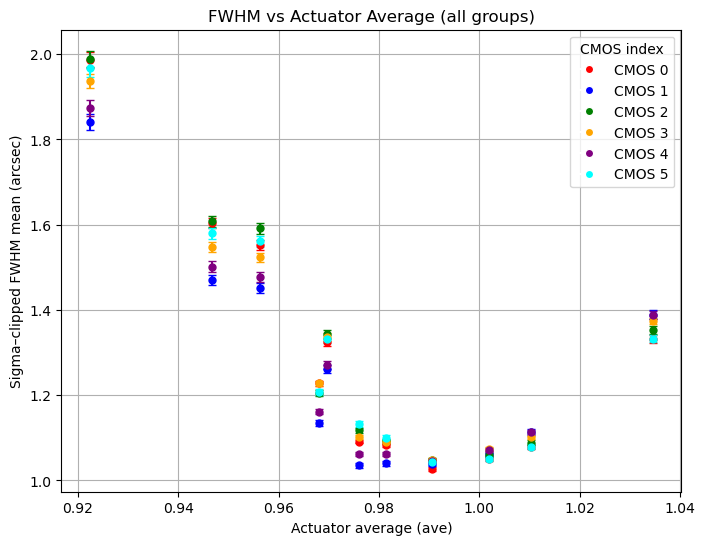

In [92]:
import matplotlib.pyplot as plt
import numpy as np

colors = ["red","blue","green","orange","purple","cyan"]

plt.figure(figsize=(8,6))

for gid in fwhm_map.keys():

    # ave（アクチュエータ平均）
    ave = focus_meta[gid]["ave"]
    if np.isnan(ave):
        continue

    for cmos_idx, stats in fwhm_map[gid].items():
        mean_val = stats["mean"]
        err_val  = stats["err"]

        if np.isnan(mean_val):
            continue

        plt.errorbar(
            ave, mean_val,
            yerr=err_val,
            fmt='o',
            color=colors[cmos_idx % len(colors)],
            markersize=5,
            capsize=3,
        )

# 軸ラベルなど
plt.xlabel("Actuator average (ave)")
plt.ylabel("Sigma–clipped FWHM mean (arcsec)")
plt.title("FWHM vs Actuator Average (all groups)")
plt.grid(True)

# 凡例（CMOSごと）
handles = [plt.Line2D([0],[0], marker='o', color='w',
            markerfacecolor=colors[i], markersize=6, label=f"CMOS {i}")
           for i in range(len(colors))]
plt.legend(handles=handles, title="CMOS index")

plt.show()


CMOS 0: best focus ≈ 1.000 (ave), FWHM ≈ 1.080 arcsec
CMOS 1: best focus ≈ 0.994 (ave), FWHM ≈ 1.073 arcsec
CMOS 2: best focus ≈ 1.000 (ave), FWHM ≈ 1.095 arcsec
CMOS 3: best focus ≈ 0.998 (ave), FWHM ≈ 1.102 arcsec
CMOS 4: best focus ≈ 0.995 (ave), FWHM ≈ 1.085 arcsec
CMOS 5: best focus ≈ 1.000 (ave), FWHM ≈ 1.090 arcsec


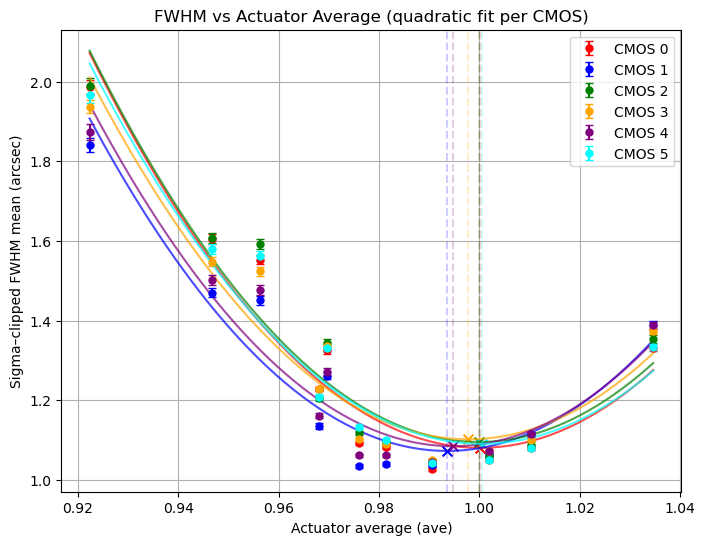

In [93]:
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

colors = ["red", "blue", "green", "orange", "purple", "cyan"]

# まず CMOSごとに (ave, mean_fwhm, err) を集約する
cmos_data = defaultdict(lambda: {"x": [], "y": [], "yerr": []})

for gid, cmos_dict in fwhm_map.items():

    # ave（アクチュエータ平均）
    ave = focus_meta[gid]["ave"]
    if np.isnan(ave):
        continue

    for cmos_idx, stats in cmos_dict.items():
        mean_val = stats["mean"]
        err_val  = stats["err"]

        if np.isnan(mean_val):
            continue

        cmos_data[cmos_idx]["x"].append(ave)
        cmos_data[cmos_idx]["y"].append(mean_val)
        cmos_data[cmos_idx]["yerr"].append(err_val)

plt.figure(figsize=(8, 6))

best_focus_results = {}  # CMOSごとの best focus を保存しておく

for cmos_idx, d in cmos_data.items():
    x = np.array(d["x"])
    y = np.array(d["y"])
    yerr = np.array(d["yerr"])

    if len(x) == 0:
        continue

    # x で並べ替え（フィット & プロットをきれいにするため）
    order = np.argsort(x)
    x = x[order]
    y = y[order]
    yerr = yerr[order]

    color = colors[cmos_idx % len(colors)]

    # --- 散布図 + エラーバー ---
    plt.errorbar(
        x, y,
        yerr=yerr,
        fmt='o',
        color=color,
        markersize=5,
        capsize=3,
        label=f"CMOS {cmos_idx}",
    )

    # --- 2次関数でフィット ---
    if len(x) >= 3:
        # y ≈ a x^2 + b x + c
        coef = np.polyfit(x, y, deg=2)
        a, b, c = coef

        # 高密度な x で滑らかな曲線を描画
        x_dense = np.linspace(x.min(), x.max(), 200)
        y_dense = np.polyval(coef, x_dense)
        plt.plot(x_dense, y_dense, color=color, alpha=0.7)

        # 頂点（best focus）: x_best = -b / (2a)
        if a != 0:
            x_best = -b / (2.0 * a)
            y_best = np.polyval(coef, x_best)

            best_focus_results[cmos_idx] = (x_best, y_best)

            # グラフ上にマーカーと縦線を入れる
            if x.min() <= x_best <= x.max():
                plt.axvline(x_best, color=color, alpha=0.2, linestyle='--')
            plt.scatter([x_best], [y_best], color=color, marker='x', s=50)

            print(f"CMOS {cmos_idx}: best focus ≈ {x_best:.3f} (ave), FWHM ≈ {y_best:.3f} arcsec")
        else:
            print(f"CMOS {cmos_idx}: quadratic fit has a=0, cannot compute vertex.")
    else:
        # 点が少ないと 2次フィットは不安定なので、その場合は線形だけでもOK
        if len(x) >= 2:
            coef = np.polyfit(x, y, deg=1)
            x_dense = np.linspace(x.min(), x.max(), 200)
            y_dense = np.polyval(coef, x_dense)
            plt.plot(x_dense, y_dense, color=color, alpha=0.7)

plt.xlabel("Actuator average (ave)")
plt.ylabel("Sigma–clipped FWHM mean (arcsec)")
plt.title("FWHM vs Actuator Average (quadratic fit per CMOS)")
plt.grid(True)
plt.legend()
plt.show()
